In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



#Part1 dataset exploration
#step1 load dataset
df = pd.read_csv("dogs_dataset1.csv")
print(df.head())

                  Breed  Age (Years)  Weight (kg)    Color  Gender
0      Airedale Terrier         13.0         35.0    White    Male
1  Jack Russell Terrier         10.0         43.0      Tan  Female
2        Dogo Argentino          2.0         16.0  Spotted  Female
3    Labrador Retriever          9.0         57.0  Bicolor    Male
4        French Bulldog         12.0          NaN  Spotted    Male


In [11]:
#step2 display shape
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (3000, 5)
Columns: ['Breed', 'Age (Years)', 'Weight (kg)', 'Color', 'Gender']


In [12]:
#step3 display datatypes
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Breed        2998 non-null   str    
 1   Age (Years)  2982 non-null   float64
 2   Weight (kg)  2989 non-null   float64
 3   Color        2996 non-null   str    
 4   Gender       2998 non-null   str    
dtypes: float64(2), str(3)
memory usage: 117.3 KB
None


In [31]:
import warnings
warnings.filterwarnings('ignore')
#step4 display summary statistics
print(df.describe())
print(df.describe(include='object'))

       Age (Years)  Weight (kg)
count  2982.000000  2989.000000
mean      7.919182    32.136166
std      15.116161    16.388620
min       1.000000     2.000000
25%       4.000000    19.000000
50%       8.000000    33.000000
75%      11.000000    45.000000
max     773.000000   299.000000
             Breed            Color  Gender
count         2998             2996    2998
unique          53               16       2
top     Rottweiler  Black and White  Female
freq           118              205    1519


In [14]:
#step5 display missing values
print(df.isnull().sum())

Breed           2
Age (Years)    18
Weight (kg)    11
Color           4
Gender          2
dtype: int64


In [15]:
#step6 display duplicate records
print('duplicated: ',df.duplicated().sum())
print(df[df.duplicated()])

duplicated:  4
                    Breed  Age (Years)  Weight (kg)    Color  Gender
1159         Irish Setter         14.0         28.0      Red  Female
2405     Golden Retriever         11.0         22.0  Bicolor  Female
2657           Bloodhound          5.0         39.0    Merle    Male
2935  Australian Shepherd          8.0         37.0    Brown    Male


In [17]:
#step7 displaay class ditribution
print(df['Gender'].value_counts())
print(df['Breed'].value_counts())

Gender
Female    1519
Male      1479
Name: count, dtype: int64
Breed
Rottweiler                       118
French Bulldog                    70
Pekingese                         68
Pembroke Welsh Corgi              67
Weimaraner                        66
Doberman Pinscher                 66
Pug                               65
Vizsla                            64
Chinese Shar-Pei                  64
Bichon Frise                      64
Cavalier King Charles Spaniel     64
Poodle                            61
Whippet                           60
Cocker Spaniel                    59
Bloodhound                        59
Dachshund                         59
Border Collie                     57
Bernese Mountain Dog              56
Samoyed                           56
Airedale Terrier                  55
Jack Russell Terrier              55
Dogo Argentino                    55
Bull Terrier                      55
Havanese                          55
Beagle                            55
Irish 

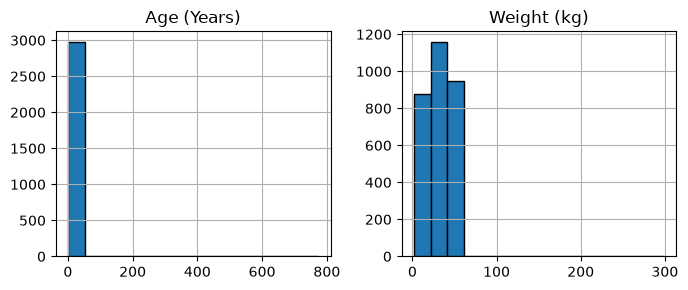

In [18]:
#Part2 data visualization
#step8 histogram
df[['Age (Years)', 'Weight (kg)']].hist(figsize=(7, 3), bins=15, edgecolor='black')
plt.tight_layout()
plt.show()

             Age (Years)  Weight (kg)
Age (Years)     1.000000    -0.027813
Weight (kg)    -0.027813     1.000000


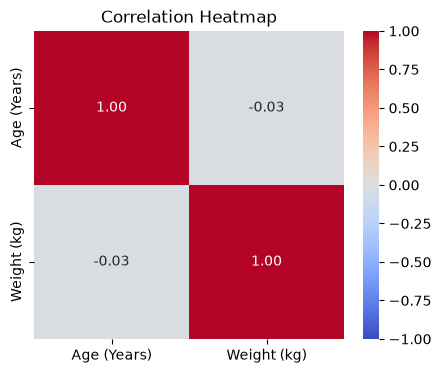

In [19]:
#step9 correlation heatmap
corr = df[['Age (Years)','Weight (kg)']].corr()
print(corr)

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

In [32]:
#Part3 data cleaning
#step10 incorrect data correction
print(df[df['Age (Years)'] > 20])
print(df[df['Weight (kg)'] > 100])

df.loc[df['Age (Years)'] > 20, 'Age (Years)'] = np.nan
df.loc[df['Weight (kg)'] > 100, 'Weight (kg)'] = np.nan

print(df[['Age (Years)', 'Weight (kg)']].describe())

               Breed  Age (Years)  Weight (kg)  Color  Gender
1086             Pug         90.0         10.0  Merle  Female
1101      Rottweiler        111.0         25.0  White  Female
1118          Poodle        130.0         27.0  Sable    Male
2708  Siberian Husky         77.0         34.0  White  Female
2734        Shih Tzu         87.0         13.0  Sable  Female
2751      Weimaraner        773.0         12.0  Sable  Female
2799       Dachshund         72.0         35.0  Sable  Female
           Breed  Age (Years)  Weight (kg) Color  Gender
2805  Lhasa Apso          6.0        299.0   Red  Female
       Age (Years)  Weight (kg)
count  2975.000000  2988.000000
mean      7.487395    32.046854
std       4.011218    15.646940
min       1.000000     2.000000
25%       4.000000    18.750000
50%       8.000000    33.000000
75%      11.000000    45.000000
max      14.000000    59.000000


In [33]:
#step11 missing value handling
print('before add value')
print(df.isnull().sum())

df['Age (Years)'] = df['Age (Years)'].fillna(df['Age (Years)'].median())
df['Weight (kg)'] = df['Weight (kg)'].fillna(df['Weight (kg)'].median())

df['Breed'] = df['Breed'].fillna(df['Breed'].mode()[0])
df['Color'] = df['Color'].fillna(df['Color'].mode()[0])
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

print('After add value')
print(df.isnull().sum())

before add value
Breed           2
Age (Years)    25
Weight (kg)    12
Color           4
Gender          2
dtype: int64
After add value
Breed          0
Age (Years)    0
Weight (kg)    0
Color          0
Gender         0
dtype: int64


In [34]:
#step12 duplicate removal
print('Num of duplicated',df.duplicated().sum())

rows_before = df.shape[0]
df = df.drop_duplicates()
rows_after = df.shape[0]

print(f"Num of rows before: {rows_before}")
print(f"Num of rows after: {rows_after}")
print(f"Remove a total of: {rows_before - rows_after} rows")

Num of duplicated 4
Num of rows before: 3000
Num of rows after: 2996
Remove a total of: 4 rows


In [35]:
#step13 data typeconversion
print(df.dtypes)

df['Age (Years)'] = df['Age (Years)'].astype(int)
df['Weight (kg)'] = df['Weight (kg)'].astype(int)

df['Breed'] = df['Breed'].astype('category')
df['Color'] = df['Color'].astype('category')
df['Gender'] = df['Gender'].astype('category')

print(df.dtypes)

Breed              str
Age (Years)    float64
Weight (kg)    float64
Color              str
Gender             str
dtype: object
Breed          category
Age (Years)       int64
Weight (kg)       int64
Color          category
Gender         category
dtype: object
